--------------------------------------------------------------------------------------------------------------
--------------------------------------COLLEY RANKING SYSTEM---------------------------------------------------
--------------------------------------------------------------------------------------------------------------

unique races in top10: 22
Sample race: [1074, 1075, 1076]

FInal Colley Ranking
   rank power_unit    rating
0     1      Honda  0.757454
1     2    Ferrari  0.562696
2     3   Mercedes  0.414431
3     4    Renault  0.265420

PU list: ['Ferrari', 'Honda', 'Mercedes', 'Renault']
Total races considered: 22


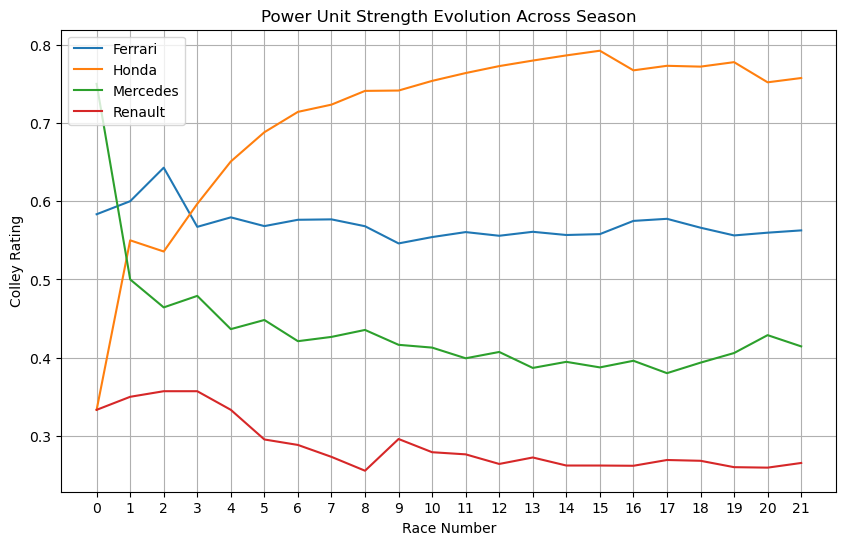

Sample raceId 1074
Race name: Bahrain Grand Prix
   position     constructor power_unit
0       1.0         Ferrari    Ferrari
1       2.0         Ferrari    Ferrari
2       3.0        Mercedes   Mercedes
3       4.0        Mercedes   Mercedes
4       5.0    Haas F1 Team    Ferrari
5       6.0      Alfa Romeo    Ferrari
6       7.0  Alpine F1 Team    Renault
7       8.0      AlphaTauri      Honda
8       9.0  Alpine F1 Team    Renault
9      10.0      Alfa Romeo    Ferrari

--------------------------------------------------------------------------------------------------------------
------------------------------------------EXPONENTIAL DECAY---------------------------------------------------
--------------------------------------------------------------------------------------------------------------

Sample race (Bahrain Grand Prix)
   position power_unit
0       1.0    Ferrari
1       2.0    Ferrari
2       3.0   Mercedes
3       4.0   Mercedes
4       5.0    Ferrari
5       6.0    F

ValueError: All arrays must be of the same length

In [3]:
print("--------------------------------------------------------------------------------------------------------------")
print("--------------------------------------COLLEY RANKING SYSTEM---------------------------------------------------") 
print("--------------------------------------------------------------------------------------------------------------")
print("")

# Loading all Neccessary Libraries
import pandas as pd
import numpy as np
from itertools import combinations
from numpy.linalg import solve
from scipy.stats import spearmanr 
import matplotlib.pyplot as plt

# COnfiguring
SEASON = 2022   
RESULTS_PATH = "results.csv"        
RACES_PATH   = "races.csv"
CONSTRUCTORS_PATH = "constructors.csv"

# Mapping all the Power Units to the Constructors 
PU_MAPPING = {
    "Red Bull": "Honda",
    "AlphaTauri": "Honda",
#     "RB F1 Team": "Honda",

    "Mercedes": "Mercedes",
    "McLaren": "Mercedes",
    "Aston Martin": "Mercedes",
    "Williams": "Mercedes",

    "Ferrari": "Ferrari",
    "Haas F1 Team": "Ferrari",
#     "Sauber": "Ferrari", 
    "Alfa Romeo": "Ferrari",

    "Alpine F1 Team": "Renault"

}

# Loading all necessary files
results = pd.read_csv(RESULTS_PATH)    
races   = pd.read_csv(RACES_PATH)
constructors = pd.read_csv(CONSTRUCTORS_PATH)

#Setting Race order for the Season
race_order = (
    races[races["year"] == SEASON]
    .sort_values("round")["raceId"]
    .tolist()
)

# normalizing all text columns (trim)
for col in ["constructor_name", "name", "position", "status"]:
    if col in results.columns:
        results[col] = results[col].astype(str).str.strip()

# Mapping COnstructor Id to each constructor 
if "constructorId" in results.columns and "constructorId" in constructors.columns:
    # constructors likely has ['constructorId', 'name']
    results = results.merge(constructors[["constructorId","name"]], how="left", left_on="constructorId", right_on="constructorId")
    results = results.rename(columns={"name":"constructor"})
results["constructor"] = results["constructor"].astype(str).str.strip()

# === 3) Filtering the Season, by excluding all the sprints
season_races = races[races["year"] == SEASON]
season_race_ids = season_races["raceId"].unique()

# If results contain session type, filter; else filter by raceId list
results = results[results["raceId"].isin(season_race_ids)]

# Some datasets include sprint_results table, making sure to exclude sprint session rows if present
if "session" in results.columns:
    results = results[results["session"].str.lower() == "race"]

# === 4) Filtering so we keep only P1-P10.
# Convert position to numeric.
results["position"] = pd.to_numeric(results["position"], errors="coerce")
top10 = results[(results["position"].notna()) & (results["position"] <= 10)].copy()

# Sanity - each race should have more than 10 rows (some races may have <10 if penalties or missing)
print("unique races in top10:", top10["raceId"].nunique())

# === 5) MAP constructors to the power_unit according ot 
    # Use provided PU_MAPPING; ensure constructor names match keys exactly
top10["power_unit"] = top10["constructor"].map(PU_MAPPING)

# Check for unmapped constructors
unmapped = top10[top10["power_unit"].isna()]["constructor"].unique()
if len(unmapped) > 0:
    print("UNMAPPED constructors (fix PU_MAPPING):", unmapped)
    # Stop here so user fixes mapping
    raise SystemExit("Please update PU_MAPPING or constructors power-unit data.")

# === 6) Build per-race PU lists (only P1-P10) 
# For each race, building a DataFrame as raceId -> list of (position, pu)
race_groups = {}
for raceId, grp in top10.groupby("raceId"):
    # create sorted list by finishing position
    race_df = grp.sort_values("position")[["position","constructor","power_unit"]].copy()
    race_groups[raceId] = race_df.reset_index(drop=True)

print("Sample race:", list(race_groups.keys())[:3])
print("")

# === 7) For each race compute PU-level as pairwise binary outcome 
pus = sorted(top10["power_unit"].unique())
P = len(pus)
pu_to_idx = {pu:i for i,pu in enumerate(pus)}

# Initializing season level matrices
N = np.zeros((P,P), dtype=int)   # number of races both PUs present in top 10
wins = np.zeros(P, dtype=int)
losses = np.zeros(P, dtype=int)

# Helping to compute pairwise wins for two PUs in a single race
def race_pair_result(race_df, puA, puB):
    # get positions of cars using puA and puB
    posA = race_df[race_df["power_unit"] == puA]["position"].values
    posB = race_df[race_df["power_unit"] == puB]["position"].values
    # if either is empty, they didn't participate in top10 therfore no comparison
    if len(posA) == 0 or len(posB) == 0:
        return None   # means no n_ij increment
    # count pairwise comparisons. every A vs every B
    a_beats_b = 0
    b_beats_a = 0
    for pa in posA:
        for pb in posB:
            if pa < pb:
                a_beats_b += 1
            elif pb < pa:
                b_beats_a += 1
            # equal shouldn't happen for unique positions
    if a_beats_b > b_beats_a:
        return 1   # A wins
    elif b_beats_a > a_beats_b:
        return -1  # B wins
    else:
        return 0   # draw

for raceId, race_df in race_groups.items():
    # for all PU pairs
    for puA, puB in combinations(pus, 2):
        res = race_pair_result(race_df, puA, puB)
        if res is None:
            continue  # at least one PU not present in top10 - skip
        i = pu_to_idx[puA]; j = pu_to_idx[puB]
        # increment n_ij
        N[i,j] += 1
        N[j,i] += 1
        if res == 1:
            wins[i] += 1
            losses[j] += 1
        elif res == -1:
            wins[j] += 1
            losses[i] += 1
        # draw -> no wins/losses increment, but N updated already

# === 8) Building the Colley matrix and solve 
games_played = N.sum(axis=1)   # t_i = sum_j n_ij (number of pairwise race comparisons participated)

C = np.zeros((P,P), dtype=float)
b = np.zeros(P, dtype=float)
for i in range(P):
    C[i,i] = 2 + games_played[i]
    b[i] = 1 + (wins[i] - losses[i]) / 2.0
    for j in range(P):
        if i != j:
            C[i,j] = -N[i,j]

ratings = solve(C, b)

# === 9) Output results 
pu_table = pd.DataFrame({
    "power_unit": pus,
    "rating": ratings
#     "wins": wins,
#     "losses": losses,
#     "games": games_played
}).sort_values("rating", ascending=False).reset_index(drop=True)
pu_table.insert(0, "rank", pu_table.index + 1)
print("FInal Colley Ranking")
print(pu_table)
print("")

# === 10) Validation checks ===
print("PU list:", pus)
# print("Games per PU (should be <= number of races):", games_played)
print("Total races considered:", len(race_groups))
# Optional - correlating with constructor points aggregated by PU


# Race-by-race Colley rating evolution

evolution = []  

# Initialize matrices to track head-ohead matchups
N = np.zeros((P, P))       
wins = np.zeros(P)         
losses = np.zeros(P)     

# Iterate through each race in chronological order
for raceId in race_order:

    # Skip races not in our grouped data
    if raceId not in race_groups:
        continue

    race_df = race_groups[raceId]  # DataFrame for the current race

    # Compare every pair of power units (PUs) in the race
    for puA, puB in combinations(pus, 2):

        # Determine head-to-head result between puA and puB
        res = race_pair_result(race_df, puA, puB)

        if res is None:
            continue  

        # Map power units to indices in matrices
        i = pu_to_idx[puA]
        j = pu_to_idx[puB]

        # Update number of encounters
        N[i, j] += 1
        N[j, i] += 1

        # Update wins and losses based on the result
        if res == 1:
            wins[i] += 1
            losses[j] += 1
        elif res == -1:
            wins[j] += 1
            losses[i] += 1


    # Build Colley matrix after this race
    
    games = N.sum(axis=1)  # Total number of games played by each PU

    C = np.zeros((P, P))  
    b = np.zeros(P)       

    for i in range(P):
        C[i, i] = 2 + games[i]            
        b[i] = 1 + (wins[i] - losses[i]) / 2  


        for j in range(P):
            if i != j:
                C[i, j] = -N[i, j]

    ratings = np.linalg.solve(C, b)

    # Record the ratings for this race
    row = {"raceId": raceId}
    for i, pu in enumerate(pus):
        row[pu] = ratings[i]

    evolution.append(row)  # Append to evolution list

# Convert evolution list to DataFrame for plotting
evolution_df = pd.DataFrame(evolution)



# Plotting the evolution of Colley ratings race by race

plt.figure(figsize=(10,6))

# Plot each PU's rating over the season
for pu in pus:
    plt.plot(evolution_df[pu], label=pu)

plt.xlabel("Race Number")
plt.ylabel("Colley Rating")
plt.title("Power Unit Strength Evolution Across Season")

plt.xticks(range(len(evolution_df)))   # Force x-axis ticks for each race
plt.legend()
plt.grid(True)
plt.show()

# First make a PU level points sum
if "points" in results.columns:
    pts = top10.groupby("power_unit")["points"].sum().reindex(pus).fillna(0).values
    corr, pval = spearmanr(ratings, pts)
#     print("Spearman correlation between Colley rating and summed PU points:", corr, "p=", pval)

# For raceId in race_groups, log pairwise results to inspect particular races
sample_race = list(race_groups.keys())[0]
print("Sample raceId", sample_race)
races_df = pd.read_csv("races.csv")

race_name = races_df.loc[races_df["raceId"] == sample_race, "name"].values[0]
print("Race name:", race_name)

print(race_groups[sample_race])
print("")
print("--------------------------------------------------------------------------------------------------------------")
print("------------------------------------------EXPONENTIAL DECAY---------------------------------------------------") 
print("--------------------------------------------------------------------------------------------------------------")
print("")

# Select only races from the chosen season
season_races = races[races["year"] == SEASON]

# Extract race IDs for that season
season_race_ids = season_races["raceId"]

# Filter results to only include those races
results = results[results["raceId"].isin(season_race_ids)]



# # Print column names to understand dataset structure
# print("RESULTS COLUMNS:\n", results.columns)
# print("\nRACES COLUMNS:\n", races.columns)
# print("\nCONSTRUCTORS COLUMNS:\n", constructors.columns)


# Merge constructor names into results using constructorId
results = results.merge(
    constructors[["constructorId", "name"]],
    on="constructorId",
    how="left"
)
# Rename 'name' column to 'constructor' for clarity
results = results.rename(columns={"name": "constructor"})


# Convert position to numeric (and make invalid values as NaN)
results["position"] = pd.to_numeric(results["position"], errors="coerce")
# Remove rows with missing/invalid positions
clean_results = results[results["position"].notna()].copy()


# print(clean_results.head())
# print("\nUnique constructors:\n", clean_results["constructor"].unique())
# print("\nPositions range:\n", clean_results["position"].min(), "to", clean_results["position"].max())


results = results.merge(
    constructors[["constructorId", "name"]],
    on="constructorId",
    how="left"
)

# Remove any old constructor columns if they exist
results = results.drop(columns=[col for col in results.columns if "constructor" in col and col != "constructorId" and col != "name"], errors="ignore")

# Rename cleanly
results = results.rename(columns={"name": "constructor"})

# print([col for col in clean_results.columns if "constructor" in col])



# Remove duplicate constructor columns (caused by multiple merges)
clean_results = clean_results.loc[:, ~clean_results.columns.duplicated()]

# Resolve constructor_x / constructor_y conflicts
if "constructor_x" in clean_results.columns:
    clean_results["constructor"] = clean_results["constructor_x"]

elif "constructor_y" in clean_results.columns:
    clean_results["constructor"] = clean_results["constructor_y"]

# Drop redundant constructor columns
clean_results = clean_results.drop(
    columns=[col for col in clean_results.columns if col.startswith("constructor_")],
    errors="ignore"
)

# print(type(clean_results["constructor"]))

# Map each constructor to its power unit
clean_results["power_unit"] = clean_results["constructor"].map(PU_MAPPING)

# Check for unmapped constructors (debugging)
# print(clean_results[clean_results["power_unit"].isna()]["constructor"].unique())


# Create dictionary of race-wise grouped data
race_groups = {}

for raceId, grp in clean_results.groupby("raceId"):
    # Sort by finishing position
    race_df = grp.sort_values("position")[["position", "power_unit"]].copy()
    # Store cleaned race data
    race_groups[raceId] = race_df.reset_index(drop=True)
    
    
# View one race sample for verification
sample_race = list(race_groups.keys())[0]
print("Sample race (Bahrain Grand Prix)")
print(race_groups[sample_race].head(10))
print("")


# Exponential Scoring Function
def compute_exponential_scores(race_groups, k=3):
    pu_scores = {}

    for raceId, race_df in race_groups.items():
        max_pos = race_df["position"].max()

        # Normalize positions between 0 and 1
        if max_pos == 1:
            race_df["p_norm"] = 0
        else:
            race_df["p_norm"] = (race_df["position"] - 1) / (max_pos - 1)

        # Apply exponential decay scoring
        race_df["score"] = np.exp(-k * race_df["p_norm"])

        # Compute average score per power unit in this race
        pu_race_scores = race_df.groupby("power_unit")["score"].mean()

        # Store scores across races
        for pu, s in pu_race_scores.items():
            pu_scores.setdefault(pu, []).append(s)

    # Final average score per power unit across all races
    final_scores = {pu: np.mean(scores) for pu, scores in pu_scores.items()}

    return final_scores


# Compute scores using exponential model
scores = compute_exponential_scores(race_groups, k=3)


# Convert to DataFrame for ranking
exp_df = pd.DataFrame({
    "power_unit": list(scores.keys()),
    "score": list(scores.values())
}).sort_values("score", ascending=False).reset_index(drop=True)

# Assign rank based on score
exp_df["rank"] = exp_df.index + 1

# Display final ranking
# print(exp_df)



# Compute rankings for each individual race using exponential scoring
def compute_race_by_race_scores(race_groups, k=3):
    race_rankings = {}

    for raceId, race_df in race_groups.items():
        max_pos = race_df["position"].max()

        # Normalize positions between 0 and 1
        if max_pos == 1:
            race_df["p_norm"] = 0
        else:
            race_df["p_norm"] = (race_df["position"] - 1) / (max_pos - 1)

        # Apply exponential decay scoring
        race_df["score"] = np.exp(-k * race_df["p_norm"])

        # Average score per power unit for this race
        pu_scores = race_df.groupby("power_unit")["score"].mean()

        # Sort to create ranking (higher score = better)
        pu_scores = pu_scores.sort_values(ascending=False)

        # Convert to structured DataFrame
        race_rank_df = pd.DataFrame({
            "power_unit": pu_scores.index,
            "score": pu_scores.values
        })

        # Assign rank based on sorted order
        race_rank_df["rank"] = race_rank_df.index + 1

        # Store per-race ranking
        race_rankings[raceId] = race_rank_df

    return race_rankings



# Generate race-by-race rankings
race_rankings = compute_race_by_race_scores(race_groups, k=3)

# Display one sample race
print("Sample race (Bahrain Grand Prix)")
sample_race = list(race_rankings.keys())[0]
print(race_rankings[sample_race])



print("")
print("")

print("FINAL RANKING")

# Display final ranking
print(exp_df)


print("")
print("--------------------------------------------------------------------------------------------------------------")
print("")


# # Track how each power unit's rank changes over races
# evolution_data = {}

# for raceId, df in race_rankings.items():
#     for _, row in df.iterrows():
#         pu = row["power_unit"]
#         evolution_data.setdefault(pu, []).append(row["rank"])

# # Convert to DataFrame (rows = race number, columns = power units)
# evolution_df = pd.DataFrame(evolution_data)

# # Set race index starting from 1
# evolution_df.index = range(1, len(evolution_df) + 1)



# plt.figure(figsize=(10,6))

# # Plot rank progression for each power unit
# for pu in evolution_df.columns:
#     plt.plot(evolution_df.index, evolution_df[pu], marker='o', label=pu)

# # Invert y-axis (rank 1 at top)
# plt.gca().invert_yaxis()

# plt.xlabel("Race Number")
# plt.ylabel("Rank")
# plt.title("Power Unit Ranking Evolution (Exponential Model)")

# plt.legend()
# plt.grid(True)
# plt.show()



# # Prepare comparison table between Colley and Exponential rankings
# comparison = pu_table[["power_unit", "rank"]].rename(columns={"rank": "colley_rank"})

# comparison = comparison.merge(
#     exp_df[["power_unit", "rank"]].rename(columns={"rank": "exp_rank"}),
#     on="power_unit"
# )




# plt.figure(figsize=(8,5))

# # Plot both ranking systems
# plt.plot(comparison["power_unit"], comparison["colley_rank"], marker='o', label="Colley")
# plt.plot(comparison["power_unit"], comparison["exp_rank"], marker='o', label="Exponential")

# # Invert y-axis (lower rank = better)
# plt.gca().invert_yaxis()

# plt.xlabel("Power Unit")
# plt.ylabel("Rank (Lower = Better)")
# plt.title("Colley vs Exponential Ranking")

# plt.legend()
# plt.xticks(rotation=45)
# plt.grid(True)
# plt.tight_layout()
# plt.show()



print("")
print("--------------------------------------------------------------------------------------------------------------")
print("")


print("FInal Colley Ranking")
print(pu_table)
print("")

print("FINAL RANKING")

# Display final ranking
print(exp_df)

